# PART 0: SETUP

## 0.1 Imports

In [1]:
# ▶ RUN THIS CELL: Import required libraries
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Figure settings for presentation-quality plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 16

print('✓ Imports successful!')

✓ Imports successful!


## 0.2 Load Connectome Data

We'll load synapse data from the **FAFB** (Full Adult Fly Brain) dataset, specifically the **central complex** region.

The data contains synaptic connections with columns:
- `pre`: presynaptic neuron ID
- `post`: postsynaptic neuron ID
- `side`: hemisphere (left/right)

In [2]:
# ▶ RUN THIS CELL: Load connectome data
import os
import pandas as pd

# Configuration
DATASET = 'fafb_783'
REGION = 'antennal_lobe'# 'central_complex'

# Try local path first, then GCS
LOCAL_PATH = f'data/{DATASET}_synapses.feather'
GCS_PATH = f'gs://sjcabs_2025_data/fafb/{REGION}/{DATASET}_{REGION}_simple_edgelist.feather'
META_PATH = f'gs://sjcabs_2025_data/fafb/{REGION}/{DATASET}_{REGION}_meta.feather'

if os.path.exists(LOCAL_PATH):
    print(f'Loading from local: {LOCAL_PATH}')
    synapses_df = pd.read_feather(LOCAL_PATH)
else:
    print(f'Loading from GCS: {GCS_PATH}')
    import gcsfs
    gcs = gcsfs.GCSFileSystem(token='google_default')
    import pyarrow.feather as feather
    with gcs.open(GCS_PATH.replace('gs://', ''), 'rb') as f:
        synapses_df = feather.read_feather(f)
    with gcs.open(META_PATH.replace('gs://', ''), 'rb') as f:
        meta_df = feather.read_feather(f)

print(f'✓ Loaded {len(synapses_df):,} synapses')
print(f'  Columns: {list(synapses_df.columns)}')
synapses_df.head()

Loading from GCS: gs://sjcabs_2025_data/fafb/antennal_lobe/fafb_783_antennal_lobe_simple_edgelist.feather
✓ Loaded 268,578 synapses
  Columns: ['pre', 'post', 'count', 'norm', 'total_input']


,pre,post,count,norm,total_input
0,720575940605758142,720575940603356128,8,0.0533,150
1,720575940616169578,720575940603356128,5,0.0333,150
2,720575940632795532,720575940603356128,16,0.1067,150
3,720575940631907159,720575940603356128,7,0.0467,150
4,720575940633294796,720575940603356128,5,0.0333,150


In [3]:
# Add edges (multiple synapses between same neurons become edge weight)
edge_counts = synapses_df
# .groupby(['pre', 'post']).size().reset_index(name='weight')

In [4]:
from scipy import sparse

# Get unique node IDs and create mapping to indices
all_nodes = pd.unique(edge_counts[['pre', 'post']].values.ravel())
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
n_nodes = len(all_nodes)

# Map pre/post to indices
row_indices = edge_counts['pre'].map(node_to_idx).values
col_indices = edge_counts['post'].map(node_to_idx).values
weights = edge_counts['norm'].values

# Create sparse adjacency matrix (CSR format for efficient row operations)
adj_matrix = sparse.csr_matrix((weights, (row_indices, col_indices)), shape=(n_nodes, n_nodes))

print(f'Sparse adjacency matrix: {adj_matrix.shape}')
print(f'  Non-zero entries: {adj_matrix.nnz:,}')
print(f'  Sparsity: {1 - adj_matrix.nnz / (n_nodes * n_nodes):.6f}')

Sparse adjacency matrix: (3532, 3532)
  Non-zero entries: 268,578
  Sparsity: 0.978471


# PART 1: Response to perturbation of neuron $i$

$$\mathbf{V} = \mathbf{x} + g\mathbf{Jx} + g^2\mathbf{J^2x} + g^3\mathbf{J^3x} + \dots$$
where $\mathbf{x}$ is the perturbation vector with $x_i = 1, x_{k\neq i} = 0$. $\mathbf{J}$ is the weighted adjacency matrix.  

In [5]:
# ▶ RUN THIS CELL: Create perturbation vector for a particular cell type population

def create_perturbation_vector_from_celltype(meta_df, CELL_TYPE, node_to_idx, ID_COLUMN = f'{DATASET}_id'):
    # Get PFNp neuron IDs from metadata
    pfnp_ids = meta_df[meta_df['cell_type'] == CELL_TYPE][ID_COLUMN].values

    # Filter to neurons that exist in our adjacency matrix
    pfnp_ids_in_graph = [nid for nid in pfnp_ids if nid in node_to_idx]

    # Create perturbation vector: x_i = 1 for all PFNp neurons, 0 otherwise
    x = np.zeros(n_nodes)
    for nid in pfnp_ids_in_graph:
        x[node_to_idx[nid]] = 1

    return x

In [6]:
# Configuration
x = sparse.csr_array(create_perturbation_vector_from_celltype(meta_df, 'DM1_lPN', node_to_idx))

print(f'DM1_pn perturbation vector created:')
print(f'  Total DM1_pn neurons in metadata: {x.sum()}')
print(f'  Perturbation vector shape: {x.shape}')
print(f'  Non-zero entries: {int(x.sum())}')

DM1_pn perturbation vector created:
  Total DM1_pn neurons in metadata: 2.0
  Perturbation vector shape: (3532,)
  Non-zero entries: 2


In [7]:
# ▶ RUN THIS CELL: Compute perturbation response V = x + gJx + g²J²x + ...

def compute_perturbation_response(J, x, g=1, n_hops=10, transpose=False):
    """
    Compute the network response to a perturbation using the power series:
    V = x + g*J*x + g²*J²*x + g³*J³*x + ... (up to n_hops)
    
    Parameters
    ----------
    J : sparse matrix
        Weighted adjacency matrix (n_nodes x n_nodes)
    x : sparse array or ndarray
        Perturbation vector (n_nodes,) or (1, n_nodes) with 1s for perturbed neurons
    g : float
        Gain/coupling constant. Controls how strongly activity propagates.
    n_hops : int
        Number of hops in the graph (k = 0, 1, ..., n_hops-1)
    transpose : bool
        If False: compute downstream effects (J propagates pre -> post)
        If True: compute upstream effects (J.T propagates post -> pre)
    
    Returns
    -------
    V : sparse array
        Response vector (1, n_nodes) - activity level at each neuron
    terms : list of sparse arrays
        Individual terms [x, gJx, g²J²x, ...] for analysis
    """
    # Use transposed matrix if requested (for upstream propagation)
    J_eff = J.T if transpose else J
    
    # Ensure x is a sparse row vector (1, n_nodes) for matrix multiplication
    if sparse.issparse(x):
        if x.ndim == 1 or x.shape[0] != 1:
            x = sparse.csr_array(x.toarray().reshape(1, -1))
    else:
        x = sparse.csr_array(np.asarray(x).reshape(1, -1))

    # Initialize: V = x (k=0 term)
    V = x.copy()
    terms = [x.copy()]
    
    # Current term starts as x, will be updated as J^k * x
    current_term = x.copy()
    
    # Add terms: g^k * J^k * x for k = 1, 2, ..., n_hops-1
    # For row vector x: x @ J gives downstream propagation
    for k in range(1, n_hops+1):
        # x @ J^k = (x @ J^(k-1)) @ J
        current_term = current_term @ J_eff
        
        # g^k * J^k * x
        scaled_term = (g ** k) * current_term
        
        V = V + scaled_term
        terms.append(scaled_term.copy())
    
    return V, terms

(array([9.000e+00, 0.000e+00, 0.000e+00, 3.000e+00, 2.000e+00, 2.000e+00,
        3.000e+00, 0.000e+00, 4.000e+00, 0.000e+00, 2.000e+00, 5.000e+00,
        3.000e+00, 4.000e+00, 1.000e+00, 1.000e+00, 5.000e+00, 2.000e+00,
        5.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 8.000e+00, 6.000e+00,
        5.000e+00, 3.000e+00, 4.000e+00, 2.000e+00, 6.000e+00, 5.000e+00,
        7.000e+00, 8.000e+00, 9.000e+00, 1.400e+01, 1.000e+01, 1.400e+01,
        2.200e+01, 1.900e+01, 3.100e+01, 3.400e+01, 3.400e+01, 4.600e+01,
        5.700e+01, 5.600e+01, 7.300e+01, 9.600e+01, 7.300e+01, 8.100e+01,
        1.880e+02, 2.561e+03, 5.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

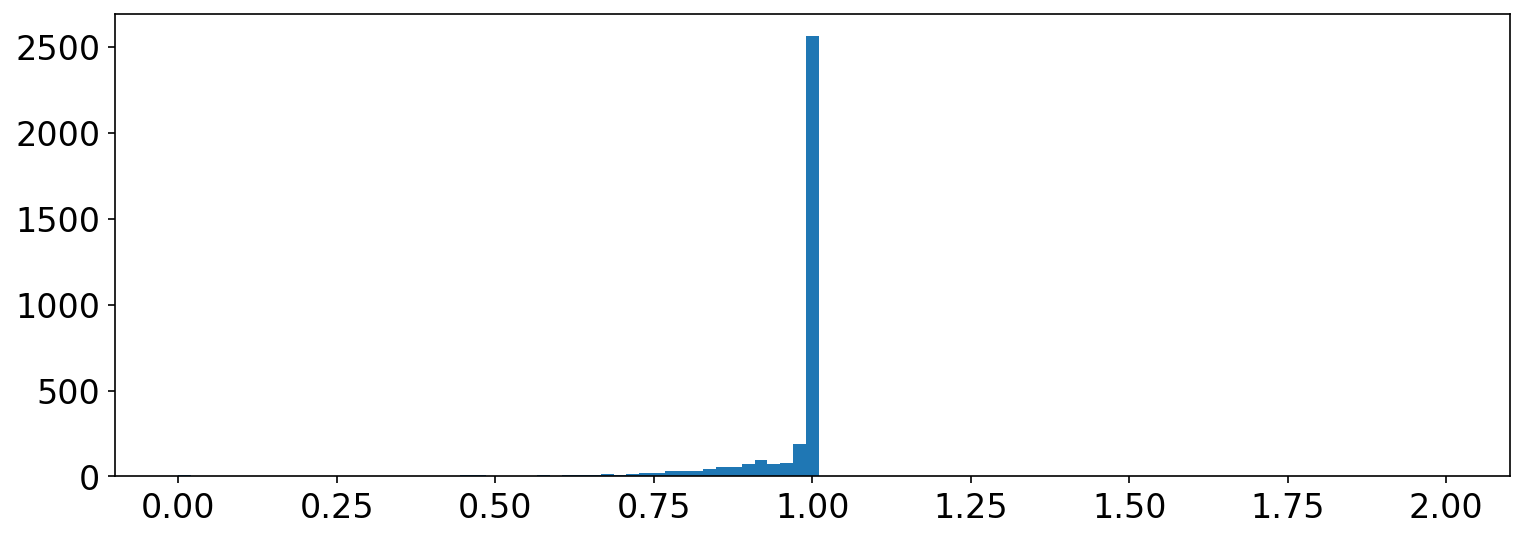

In [ ]:
# plt.hist(adj_matrix.toarray().sum(axis=0), bins=np.linspace(0,2,100))
# # np.sum((adj_matrix.sum(axis=1) < 1.05) & (adj_matrix.sum(axis=1) > 0.95))

In [12]:
# Example usage with the DM1_lPN perturbation
g = 1          # Gain constant
n_hops = 3     # Number of hops in graph

# Row-normalize the adjacency matrix (each row sums to 1)
# This normalizes by out-degree: J_normalized[i,j] = J[i,j] / sum(J[i,:])
# row_sums = np.array(adj_matrix.sum(axis=1)).flatten()
# row_sums[row_sums == 0] = 1  # Avoid division by zero for nodes with no outgoing edges
# inv_row_sums = sparse.diags(1.0 / row_sums)
# adj_matrix_norm = inv_row_sums @ adj_matrix
adj_matrix_norm = adj_matrix.copy()

V_downstream, terms_downstream = compute_perturbation_response(
    adj_matrix_norm, x, g=g, n_hops=n_hops, transpose=False
)
V_upstream, terms_upstream = compute_perturbation_response(
    adj_matrix_norm, x, g=g, n_hops=n_hops, transpose=True
)

print(f'Perturbation Response Computed:')
print(f'  Parameters: g={g}, n_hops={n_hops}')
print(f'  Input neurons perturbed: {int(x.sum())}')
print(f'')
print(f'  Downstream (J): neurons with V > 0: {(V_downstream.toarray() > 0).sum()}')
print(f'  Downstream max response: {V_downstream.max():.4f}')
print(f'')
print(f'  Upstream (J.T): neurons with V > 0: {(V_upstream.toarray() > 0).sum()}')
print(f'  Upstream max response: {V_upstream.max():.4f}')

# Print nonzero entries at each hop level
print(f'\n--- Nonzero entries per hop (Downstream) ---')
for k, term in enumerate(terms_downstream):
    nnz = (term.toarray() > 0).sum()
    print(f'  Hop {k}: {nnz} nonzero entries')

print(f'\n--- Nonzero entries per hop (Upstream) ---')
for k, term in enumerate(terms_upstream):
    nnz = (term.toarray() > 0).sum()
    print(f'  Hop {k}: {nnz} nonzero entries')

Perturbation Response Computed:
  Parameters: g=1, n_hops=3
  Input neurons perturbed: 2

  Downstream (J): neurons with V > 0: 3523
  Downstream max response: 1.0192

  Upstream (J.T): neurons with V > 0: 3522
  Upstream max response: 1.0199

--- Nonzero entries per hop (Downstream) ---
  Hop 0: 2 nonzero entries
  Hop 1: 338 nonzero entries
  Hop 2: 3514 nonzero entries
  Hop 3: 3523 nonzero entries

--- Nonzero entries per hop (Upstream) ---
  Hop 0: 2 nonzero entries
  Hop 1: 346 nonzero entries
  Hop 2: 3429 nonzero entries
  Hop 3: 3522 nonzero entries


In [32]:
# ▶ RUN THIS CELL: Plotly bar plot colored by g values with n_hops slider
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc

# Create mapping from index to node ID
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# Get cell class for each node in the graph
ID_COLUMN = f'{DATASET}_id'
meta_lookup = meta_df.set_index(ID_COLUMN)['cell_class'].to_dict()

cell_classes = []
for i in range(n_nodes):
    node_id = idx_to_node[i]
    cc = meta_lookup.get(node_id)
    cell_classes.append(cc if cc is not None else 'Unknown')
cell_classes = np.array(cell_classes)

# Parameters
g_values = [.1, 0.5, 0.75, 1.0, 1.5, 2.0]
n_hops_values = [1, 2, 3, 4, 5, 6, 7, 8]

# Color map for g values
colors = pc.sample_colorscale('Viridis', [i / (len(g_values) - 1) for i in range(len(g_values))])

# Precompute responses for all combinations
all_results = {}
for n_hops in n_hops_values:
    all_results[n_hops] = {}
    for g_val in g_values:
        V_downstream, _ = compute_perturbation_response(adj_matrix_norm, x, g=g_val, n_hops=n_hops, transpose=False)
        V_upstream, _ = compute_perturbation_response(adj_matrix_norm, x, g=g_val, n_hops=n_hops, transpose=True)
        
        V_down = V_downstream.toarray().flatten()
        V_up = V_upstream.toarray().flatten()
        
        # Compute average V for each cell class
        unique_classes = np.unique(cell_classes)
        avg_downstream = {}
        avg_upstream = {}
        
        for cc in unique_classes:
            mask = cell_classes == cc
            if mask.sum() > 0:
                avg_downstream[cc] = V_down[mask].mean()
                avg_upstream[cc] = V_up[mask].mean()
        
        all_results[n_hops][g_val] = {'downstream': avg_downstream, 'upstream': avg_upstream}

print(f'Precomputed {len(n_hops_values)} n_hops x {len(g_values)} g values')

# Get all cell classes that have non-zero response for any combination
all_classes = set()
for n_hops in n_hops_values:
    for g_val in g_values:
        for cc, val in all_results[n_hops][g_val]['downstream'].items():
            if val > 0:
                all_classes.add(cc)
        for cc, val in all_results[n_hops][g_val]['upstream'].items():
            if val > 0:
                all_classes.add(cc)

# Sort by downstream response at g=1.0, n_hops=3
class_order = sorted(all_classes, key=lambda cc: all_results[3][1.0]['downstream'].get(cc, 0), reverse=True)

# Create figure
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Downstream Response (J)', 'Upstream Response (J.T)'),
    shared_yaxes=True,
    horizontal_spacing=0.15
)

# Add traces for each n_hops value (grouped by g)
default_n_hops = 3
traces_per_nhops = len(g_values) * 2  # downstream + upstream for each g

# Track trace indices for each g value (for legend interactivity)
trace_indices_by_g = {g_val: [] for g_val in g_values}

trace_count = 0
for n_hops in n_hops_values:
    visible = (n_hops == default_n_hops)
    
    for i, g_val in enumerate(g_values):
        # Downstream
        values_down = [all_results[n_hops][g_val]['downstream'].get(cc, 0) for cc in class_order]
        fig.add_trace(go.Bar(
            x=values_down,
            y=class_order,
            orientation='h',
            name=f'g={g_val}',
            marker_color=colors[i],
            opacity=0.8,
            visible=visible,
            legendgroup=f'g={g_val}',
            showlegend=False
        ), row=1, col=1)
        trace_indices_by_g[g_val].append(trace_count)
        trace_count += 1
        
        # Upstream
        values_up = [all_results[n_hops][g_val]['upstream'].get(cc, 0) for cc in class_order]
        fig.add_trace(go.Bar(
            x=values_up,
            y=class_order,
            orientation='h',
            name=f'g={g_val}',
            marker_color=colors[i],
            opacity=0.8,
            visible=visible,
            legendgroup=f'g={g_val}',
            showlegend=False
        ), row=1, col=2)
        trace_indices_by_g[g_val].append(trace_count)
        trace_count += 1

# Add dummy traces for legend (always visible, no data)
for i, g_val in enumerate(g_values):
    fig.add_trace(go.Bar(
        x=[None],
        y=[None],
        name=f'g={g_val}',
        marker_color=colors[i],
        legendgroup=f'g={g_val}',
        showlegend=True,
        visible=True
    ))

# Create slider steps
steps = []
total_traces = len(n_hops_values) * traces_per_nhops
for idx, n_hops in enumerate(n_hops_values):
    visibility = [False] * total_traces + [True] * len(g_values)  # Keep legend traces visible
    # Show all traces for this n_hops
    start_idx = idx * traces_per_nhops
    for i in range(traces_per_nhops):
        visibility[start_idx + i] = True
    
    step = dict(
        method='update',
        args=[{'visible': visibility},
              {'title': f'Perturbation Response by Cell Class (n_hops={n_hops})'}],
        label=str(n_hops)
    )
    steps.append(step)

# Layout
fig.update_layout(
    title=f'Perturbation Response by Cell Class (n_hops={default_n_hops})',
    height=750,
    barmode='group',
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.08,
        xanchor='center',
        x=0.5,
        title=dict(text='Click to toggle g values:', font=dict(size=12)),
        font=dict(size=12),
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='gray',
        borderwidth=1,
        itemclick='toggle',
        itemdoubleclick='toggleothers'
    ),
    sliders=[dict(
        active=n_hops_values.index(default_n_hops),
        currentvalue={'prefix': 'n_hops = ', 'visible': True, 'xanchor': 'center'},
        pad={'t': 60},
        steps=steps
    )],
    margin=dict(t=120)
)

fig.update_xaxes(title_text='Average Response V', row=1, col=1)
fig.update_xaxes(title_text='Average Response V', row=1, col=2)
fig.update_yaxes(title_text='Cell Class', row=1, col=1)

fig.show()

Precomputed 8 n_hops x 6 g values
